In [130]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.preprocessing import LabelEncoder, StandardScaler,MultiLabelBinarizer
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA

In [131]:
df = pd.read_csv("cleaned_data.csv")

In [140]:
import plotly.express as px

order = [
    'Teen Boy', 'Teen Girl',
    'Adult Male', 'Adult Female',
    'Middle Age Male', 'Middle Age Female',
    'Elderly Male', 'Elderly Female'
]

color_map = {
    'Minimal change': 'orange',
    'Same as before': 'green',
    'Noticeable change': 'red'
}
fig = px.bar(
    df,
    x='Category',
    color='Compared to pre-COVID, your overall health condition is',
    category_orders={'Category': order},
    color_discrete_map=color_map,
    title="Health Condition Across Categories"
)

fig.update_layout(
    barmode='stack',   
    yaxis_title="Counts",
    xaxis_title="Category"
)

fig.show()

In [146]:
color_map = {
    'Minimal change': 'blue',
    'Same as before': 'green',
    'Noticeable change': 'red'
}
fig = px.pie(df, 
             names='Compared to pre-COVID, your overall health condition is',
                color='Compared to pre-COVID, your overall health condition is',
                color_discrete_map=color_map,
             title="Overall Health Condition Distribution"
             )
fig.show()

In [79]:
#DESCRIPTIVE STATISTICS (Central Tendencies)
df['Stress level'] = pd.to_numeric(df['Stress level'], errors='coerce')

print("Mean Stress:", df['Stress level'].mean())
print("Median Stress:", df['Stress level'].median())
print("Mode Stress:", df['Stress level'].mode())

Mean Stress: 1.0
Median Stress: 1.0
Mode Stress: 0    1
Name: Stress level, dtype: int64


In [80]:
import plotly.graph_objects as go

fig = go.Figure()

# First appearance
fig.add_trace(go.Histogram(
    x=df['When did symptoms FIRST appear?'],
    name='First Appearance',
    opacity=0.6
))

# Reappearance
fig.add_trace(go.Histogram(
    x=df['Did the SAME symptoms reappear later? If YES, when did they reappear?'],
    name='Reappearance',
    opacity=0.6
))

fig.update_layout(
    barmode='overlay',
    title="First Appearance vs Reappearance of Symptoms",
    yaxis_title="Count of people",
    xaxis_title="Timeline"
)


fig.show()

In [81]:
df['Stress level'] = pd.to_numeric(df['Stress level'], errors='coerce')
df['Depression  level'] = pd.to_numeric(df['Depression  level'], errors='coerce')
df['Decrease in Patience level'] = pd.to_numeric(df['Decrease in Patience level'], errors='coerce')

mental = df.groupby('Category')[['Stress level', 'Depression  level', 'Decrease in Patience level']].mean().reset_index()
mental_melt = mental.melt(id_vars='Category', 
                          var_name='Metric', 
                          value_name='Value')
import plotly.express as px

color_map = {
    'Stress level': 'lightpink',
    'Depression level': 'lightblue',
    'Decrease in Patience level': 'lightyellow'
}

fig = px.bar(
    mental_melt,
    x='Category',
    y='Value',
    color='Metric',
    barmode='group',
    color_discrete_map=color_map,
    title="Mental Health Comparison Across Categories"
)

fig.update_layout(
    yaxis_title="Average Level(0-2 Level of change)",
    xaxis_title="Category"
)

fig.show()

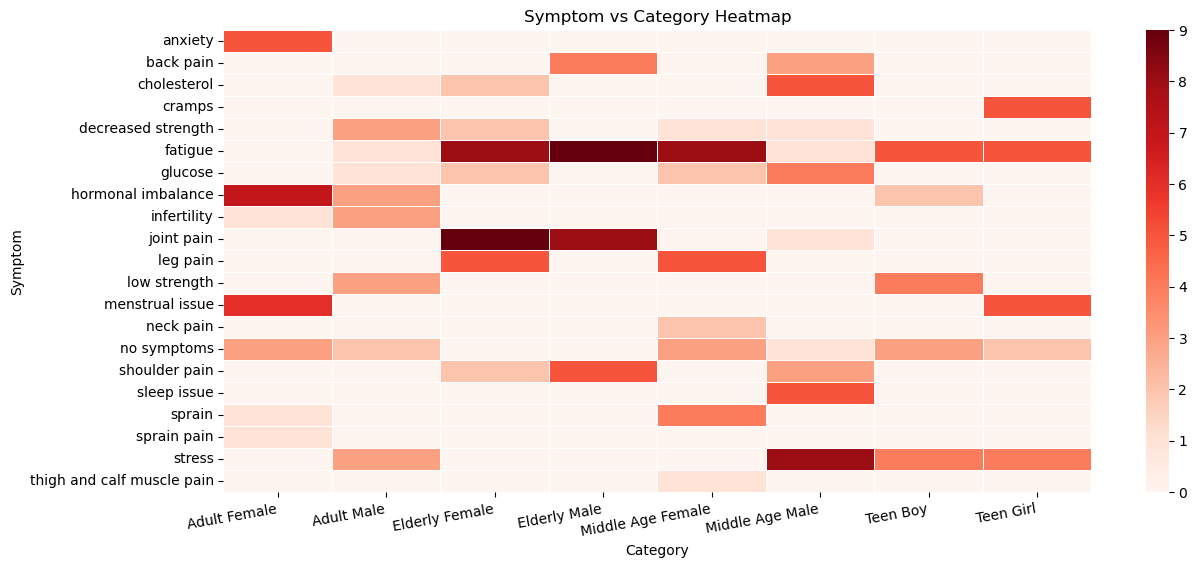

In [128]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import ast

data = []

for _, row in df.iterrows():
    cat = row['Category']
    
    s_list = row['Symptoms_processed']
    
    if isinstance(s_list, str):
        s_list = ast.literal_eval(s_list)
    
    for s in s_list:
        data.append([cat, s])

df_temp = pd.DataFrame(data, columns=['Category', 'Symptom'])

pivot = pd.crosstab(df_temp['Category'], df_temp['Symptom'])

plt.figure(figsize=(14,6))

sns.heatmap(pivot.T, cmap="Reds", linewidths=0.5) 
plt.xticks(rotation=10, ha='right')  

plt.title("Symptom vs Category Heatmap")
plt.show()

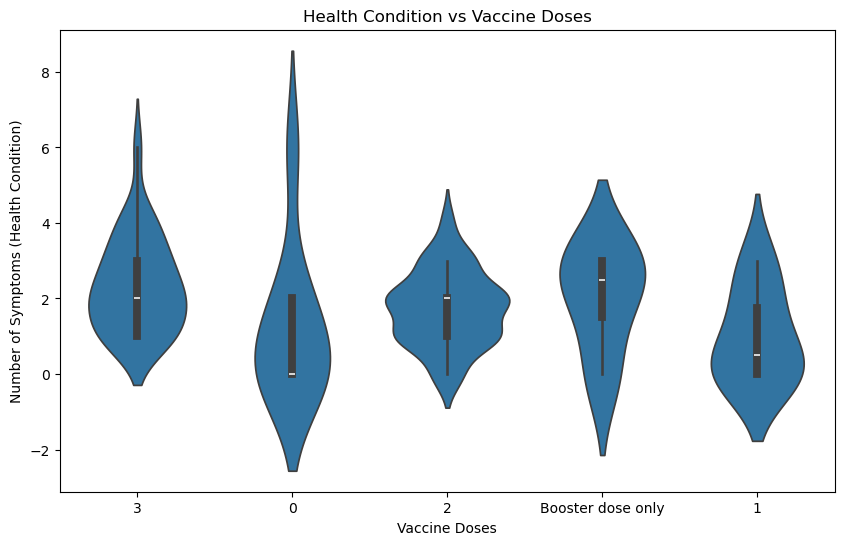

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import ast

df.columns = df.columns.str.strip()

# List format
df["Symptoms_processed"] = df["Symptoms_processed"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

# symptom count 
df["symptom_count"] = df["Symptoms_processed"].apply(
    lambda x: 0 if "no symptoms" in x else len(x)
)

plt.figure(figsize=(10,6))

sns.violinplot(
    x="Number of vaccine doses received",
    y="symptom_count",
    data=df,
    inner="box"
)

plt.xlabel("Vaccine Doses")
plt.ylabel("Number of Symptoms (Health Condition)")
plt.title("Health Condition vs Vaccine Doses")

plt.show()

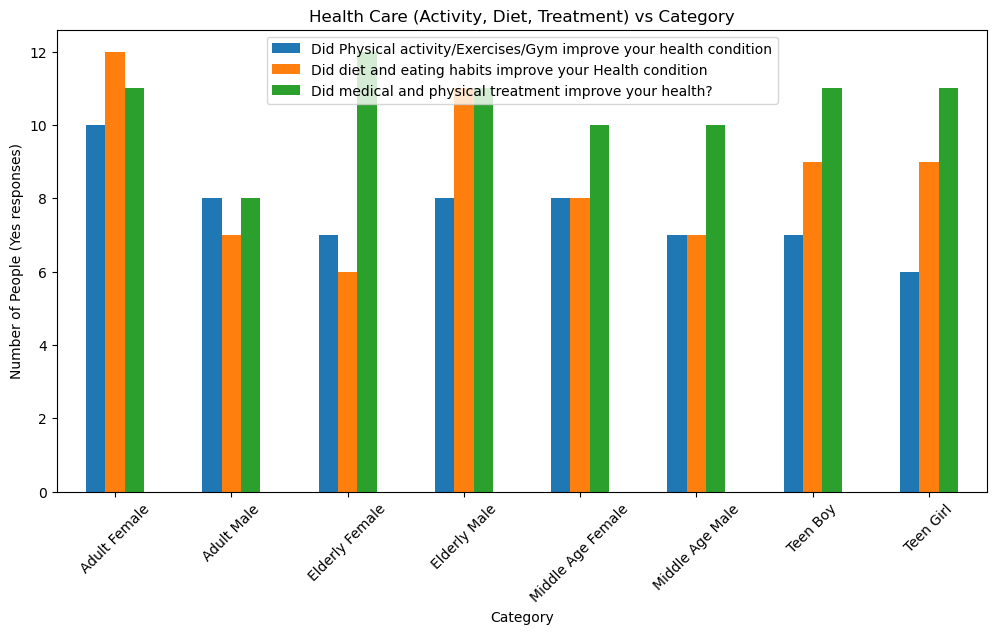

In [147]:
import pandas as pd
import matplotlib.pyplot as plt

df.columns = df.columns.str.strip()

cols = [
    "Did Physical activity/Exercises/Gym improve your health condition",
    "Did diet and eating habits improve your Health condition",
    "Did medical and physical treatment improve your health?"
]

pivot = df.groupby("Category")[cols].apply(lambda x: x.apply(lambda y: (y == "Yes").sum()))

pivot.plot(kind="bar", figsize=(12,6))

plt.xlabel("Category")
plt.ylabel("Number of People (Yes responses)")
plt.title("Health Care (Activity, Diet, Treatment) vs Category")
plt.xticks(rotation=45)

plt.show()